# **Cálculo de Indicadores (KPIs)**

**Objetivo:** Los estudiantes aprenderán a calcular indicadores clave como el Costo de Adquisición de Clientes (CAC) y el Valor de Vida del Cliente (LTV) utilizando datos reales de una startup ficticia, y a analizar cómo estos KPIs pueden influir en las decisiones estratégicas de negocio.

---

## **Estructura de la clase**

### **1. Introducción al caso práctico (10 minutos)**

**Escenario:**
Eres parte de la junta directiva de una startup ficticia en el sector de comercio electrónico. El equipo directivo necesita entender cómo optimizar sus estrategias de marketing y mejorar el retorno sobre inversión. Para ello, solicita las siguientes métricas:
1. **Costo de Adquisición de Clientes (CAC):** ¿Cuánto cuesta adquirir un cliente por mes?
2. **Valor de Vida del Cliente (LTV):** ¿Cuál es el valor promedio generado por cliente y cohort?
3. **Análisis:** ¿Cuál es el cliente con mayor LTV? ¿Cuál es el cohort con el mayor LTV promedio?

---

### **2. Introducción a las funciones en Python (10 minutos)**

#### **¿Qué es una función y cuándo se usa?**

Una función en Python es un bloque de código reutilizable que realiza una tarea específica. Se utiliza para:
- Evitar duplicar código.
- Organizar y estructurar mejor los programas.
- Facilitar la depuración y el mantenimiento.
- Hacer el código más legible y reutilizable.

**Sintaxis básica:**

In [ ]:
# Definición de una función
def nombre_funcion(parametro1, parametro2=2):
    """Descripción de lo que hace la función."""
    # Código de la función
    return resultado

# Llamada a la función
resultado = nombre_funcion(arg1, arg2)

**Ejemplo:**

In [10]:
def calcular_cac(marketing_expense, num_customers):
    """Calcula el Costo de Adquisición de Clientes."""
    return marketing_expense / num_customers

# Uso de la función
cac = calcular_cac(5000, 100)
print(f"El CAC es: {cac}")

El CAC es: 50.0


### **3. Preparación de datos (15 minutos)**

1. **Carga de datos:** Los estudiantes cargarán los datasets proporcionados:

In [12]:
import pandas as pd

customers_ids = pd.read_csv('data/customer_ids.csv')
purchases = pd.read_csv('data/purchases.csv')
marketing_expenses = pd.read_csv('data/marketing_expenses.csv')

2. **Exploración inicial:**
- Inspeccionar las primeras filas de cada DataFrame:

In [14]:
print(customers_ids.head())

   customer_id join_date
0         1000   2020-05
1         1001   2019-03
2         1002   2018-08
3         1003   2019-09
4         1004   2019-07


In [16]:
print(purchases.head())

   customer_id purchase_date  purchase_amount
0         1000       2020-12       380.786751
1         1001       2021-01       137.592776
2         1001       2020-05       331.312056
3         1001       2019-04       114.376910
4         1002       2020-05       150.824205


In [18]:
print(marketing_expenses.head())

     month  marketing_expense
0  2018-01        5524.693974
1  2018-02        7818.313887
2  2018-03        7096.517853
3  2018-04        4557.292041
4  2018-05        5372.740000


- Revisar la estructura y tipos de datos:

In [20]:
customers_ids.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  300 non-null    int64 
 1   join_date    300 non-null    object
dtypes: int64(1), object(1)
memory usage: 4.8+ KB


In [22]:
purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1544 entries, 0 to 1543
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      1544 non-null   int64  
 1   purchase_date    1544 non-null   object 
 2   purchase_amount  1544 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 36.3+ KB


In [24]:
marketing_expenses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   month              36 non-null     object 
 1   marketing_expense  36 non-null     float64
dtypes: float64(1), object(1)
memory usage: 708.0+ bytes


In [34]:
customers_ids.head(2)

,customer_id,join_date
0,1000,2020-05
1,1001,2019-03


In [36]:
purchases.head(2)

,customer_id,purchase_date,purchase_amount
0,1000,2020-12,380.786751
1,1001,2021-01,137.592776


In [40]:
clientes = customers_ids.copy()

3. **Unión de datasets:** Integrar los datos necesarios para el análisis:

In [42]:
customer_purchases = purchases.merge(clientes, on='customer_id', how='inner')
print(customer_purchases.head())

   customer_id purchase_date  purchase_amount join_date
0         1000       2020-12       380.786751   2020-05
1         1001       2021-01       137.592776   2019-03
2         1001       2020-05       331.312056   2019-03
3         1001       2019-04       114.376910   2019-03
4         1002       2020-05       150.824205   2018-08


---

### **4. Cálculo de KPIs (40 minutos)**

#### **4.1. Costo de Adquisición de Clientes (CAC):**
1. **Calcular clientes nuevos por mes:**

In [62]:
new_customers = clientes.groupby('join_date').count()

In [64]:
new_customers

,customer_id
join_date,
2018-01,8
2018-02,13
2018-03,11
2018-04,7
2018-05,5
2018-06,7
2018-07,9
2018-08,10
2018-09,9


In [66]:
marketing_expenses.head(2)

,month,marketing_expense
0,2018-01,5524.693974
1,2018-02,7818.313887


2. **Unir con los gastos de marketing:**

In [68]:
marketing_expenses.rename(columns={'month': 'join_date'}, inplace=True)

In [74]:
cac_table2 = marketing_expenses.merge(new_customers, left_on="join_date", right_index=True)

In [76]:
cac_table = marketing_expenses.join(new_customers, on='join_date')

In [78]:
cac_table.head(2)

,join_date,marketing_expense,customer_id
0,2018-01,5524.693974,8
1,2018-02,7818.313887,13


In [80]:
cac_table['cac'] = cac_table['marketing_expense'] / cac_table['customer_id']

3. **Visualizar el CAC:**

<Axes: title={'center': 'Costo de Adquisición de Clientes por Mes'}, xlabel='join_date'>

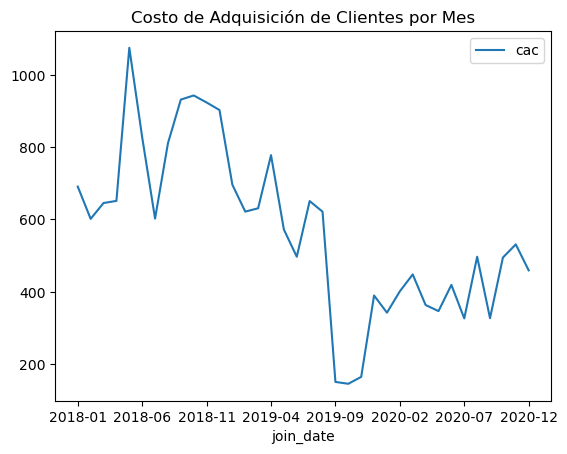

In [82]:
cac_table.plot(x='join_date', y='cac', title='Costo de Adquisición de Clientes por Mes')

#### **4.2. Valor de Vida del Cliente a 2 años (LTV 2 años):**
1. **Calcular el total de compras por cliente de los primeros 24 meses:**

In [84]:
customer_purchases.head(2)

,customer_id,purchase_date,purchase_amount,join_date
0,1000,2020-12,380.786751,2020-05
1,1001,2021-01,137.592776,2019-03


In [86]:
customer_purchases_test = customer_purchases.copy()

In [96]:
customer_purchases_test["old_cliente"] = customer_purchases_test["join_date"].apply(lambda x: True if x < "2019-01" else False)

In [98]:
customer_purchases_test.tail()

,customer_id,purchase_date,purchase_amount,join_date,old_cliente
1539,1299,2020-10,181.053054,2019-08,False
1540,1299,2021-05,335.034348,2019-08,False
1541,1299,2021-02,380.455838,2019-08,False
1542,1299,2020-11,372.044754,2019-08,False
1543,1299,2021-04,263.260676,2019-08,False


In [104]:
customer_purchases['tenure_months'] = (
    pd.to_datetime(customer_purchases['purchase_date']).dt.to_period('M') -
    pd.to_datetime(customer_purchases['join_date']).dt.to_period('M')
).apply(lambda x: x.n)

In [106]:
customer_purchases.head(2)

,customer_id,purchase_date,purchase_amount,join_date,tenure_months
0,1000,2020-12,380.786751,2020-05,7
1,1001,2021-01,137.592776,2019-03,22


In [110]:
customer_purchases[(customer_purchases['tenure_months'] <= 24) & (customer_purchases['purchase_date']<'2020-12')]

,customer_id,purchase_date,purchase_amount,join_date,tenure_months
2,1001,2020-05,331.312056,2019-03,14
3,1001,2019-04,114.376910,2019-03,1
4,1002,2020-05,150.824205,2018-08,21
5,1002,2020-05,308.897304,2018-08,21
6,1002,2019-12,407.997421,2018-08,16
...,...,...,...,...,...
1530,1297,2019-01,321.351606,2018-07,6
1531,1297,2019-09,356.652764,2018-07,14
1532,1297,2018-12,381.516924,2018-07,5
1539,1299,2020-10,181.053054,2019-08,14


In [112]:
ltv_24_months = customer_purchases[customer_purchases['tenure_months'] <= 24]

In [114]:
ltv_24_months

,customer_id,purchase_date,purchase_amount,join_date,tenure_months
0,1000,2020-12,380.786751,2020-05,7
1,1001,2021-01,137.592776,2019-03,22
2,1001,2020-05,331.312056,2019-03,14
3,1001,2019-04,114.376910,2019-03,1
4,1002,2020-05,150.824205,2018-08,21
...,...,...,...,...,...
1539,1299,2020-10,181.053054,2019-08,14
1540,1299,2021-05,335.034348,2019-08,21
1541,1299,2021-02,380.455838,2019-08,18
1542,1299,2020-11,372.044754,2019-08,15


In [116]:
customer_ltv = ltv_24_months.groupby('customer_id')['purchase_amount'].sum()

In [118]:
print(customer_ltv.head())

customer_id
1000     380.786751
1001     583.281742
1002    2286.811107
1003    2062.970211
1004    2773.921671
Name: purchase_amount, dtype: float64


In [120]:
ltv_24_months

,customer_id,purchase_date,purchase_amount,join_date,tenure_months
0,1000,2020-12,380.786751,2020-05,7
1,1001,2021-01,137.592776,2019-03,22
2,1001,2020-05,331.312056,2019-03,14
3,1001,2019-04,114.376910,2019-03,1
4,1002,2020-05,150.824205,2018-08,21
...,...,...,...,...,...
1539,1299,2020-10,181.053054,2019-08,14
1540,1299,2021-05,335.034348,2019-08,21
1541,1299,2021-02,380.455838,2019-08,18
1542,1299,2020-11,372.044754,2019-08,15


2. **Promedio de LTV por cohort:**

In [122]:
cohort_ltv = ltv_24_months.groupby('join_date')['purchase_amount'].mean()
cohort_ltv.head()

join_date
2018-01    326.488462
2018-02    298.892739
2018-03    301.848230
2018-04    269.584157
2018-05    290.785516
Name: purchase_amount, dtype: float64

<Axes: title={'center': 'LTV Promedio por Cohort'}, xlabel='join_date'>

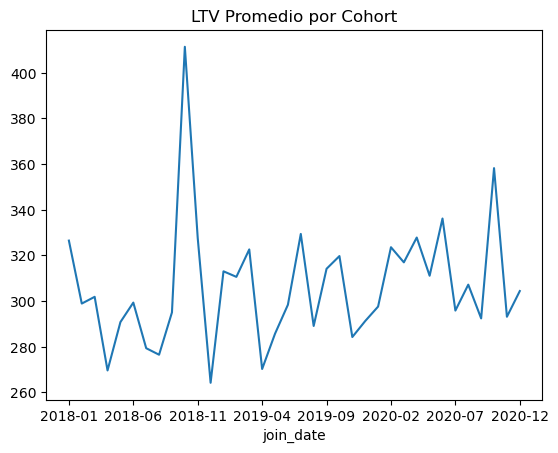

In [124]:
cohort_ltv = ltv_24_months.groupby('join_date')['purchase_amount'].mean()
cohort_ltv.plot(title='LTV Promedio por Cohort')

#### **4.3. Identificar clientes y cohorts destacados:**
- Cliente con mayor LTV:

In [126]:
customer_ltv.head()

customer_id
1000     380.786751
1001     583.281742
1002    2286.811107
1003    2062.970211
1004    2773.921671
Name: purchase_amount, dtype: float64

In [128]:
top_customer = customer_ltv.idxmax()
print(f"El cliente con mayor LTV es: {top_customer}")

El cliente con mayor LTV es: 1025


- Cohort con mayor LTV promedio:

In [138]:
cohort_ltv.nlargest(5)

join_date
2018-10    411.428776
2020-10    358.247659
2020-06    336.171121
2019-07    329.405916
2020-04    327.831050
Name: purchase_amount, dtype: float64

In [134]:
top_cohort = cohort_ltv.idxmax()
print(f"El cohort con mayor LTV promedio es: {top_cohort}")

El cohort con mayor LTV promedio es: 2018-10



---

### **5. Análisis estratégico (20 minutos)**

**Discusión en grupos de 3 personas:**
- Cada grupo analiza los resultados obtenidos y responde:
- ¿Qué estrategias implementarían para reducir el CAC?
- ¿Cómo podrían aumentar el LTV de los clientes?

**Presentación:**
- Cada grupo menciona una estrategia basada en los datos obtenidos.

**Instrucciones para el reporte de laboratorio:**

- Cada estudiante debe crear un reporte en Jupyter Notebook que contenga:

    - Introducción al caso y explicación de los KPIs calculados.

    - Código utilizado para calcular el CAC y LTV.

    - Visualizaciones generadas (gráficas de CAC y LTV por cohort).

    - Respuestas a las preguntas clave:

        - ¿Cuál es el cliente con mayor LTV?

        - ¿Cuál es el cohort con el mayor LTV promedio?

    - Una propuesta breve de estrategias para reducir el CAC y aumentar el LTV.

- Entrega:

    - Subir el archivo .ipynb con el reporte a Canvas antes de la próxima sesión.



---

### **6. Cierre y asignación (5 minutos)**

- **Reflexión:**
    - Repasar cómo los KPIs calculados pueden influir en decisiones estratégicas.
    - Enfatizar la importancia de un análisis basado en datos.
- **Asignación:**
    - Investigar un caso real donde se utilicen KPIs como CAC y LTV para tomar decisiones.

<script>
  $(document).ready(function(){
    $('div.prompt').hide();
    $('div.back-to-top').hide();
    $('nav#menubar').hide();
    $('.breadcrumb').hide();
    $('.hidden-print').hide();
  });
</script>

<footer id="attribution" style="float:right; color:#808080; background:#fff;">
Created with Jupyter by Carlos Kelly
</footer>